In [2]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [30]:
pdf1 = pl.read_csv("ESS8e02_3.csv")
pdf2 = pl.read_csv("ESS10e03_3.csv")
pdf3 = pl.read_csv("ESS11e04_1.csv")

In [34]:
df1 = pdf1.filter(pl.col("cntry") == "HU").select("idno","wrclmch","edulvlb","agea","netustm",
                                           "gndr","hinctnta","lrscale","region",
                                           "happy","stflife","stfgov").with_columns(pl.lit(1).alias("year"))
df1 = df1.rename({"idno":"id","wrclmch":"climate_worry","edulvlb":"education","agea":"age",
                                           "gndr":"gender","hinctnta":"income","lrscale":"right_orientation",
                                           "happy":"happiness","stflife":"life_satisfaction","netustm":"net_use",
                                           "stfgov":"satisfaction_with_government"})
df2 = pdf2.filter(pl.col("cntry") == "HU").select("idno","wrclmch","edulvlb","agea","netustm",
                                           "gndr","hinctnta","lrscale","region",
                                           "happy","stflife","stfgov").with_columns(pl.lit(2).alias("year"))
df2 = df2.rename({"idno":"id","wrclmch":"climate_worry","edulvlb":"education","agea":"age",
                                           "gndr":"gender","hinctnta":"income","lrscale":"right_orientation",
                                           "happy":"happiness","stflife":"life_satisfaction","netustm":"net_use",
                                           "stfgov":"satisfaction_with_government"})
df3 = pdf3.filter(pl.col("cntry") == "HU").select("idno","wrclmch","edulvlb","agea","netustm",
                                           "gndr","hinctnta","lrscale","region",
                                           "happy","stflife","stfgov").with_columns(pl.lit(3).alias("year"))
df3 = df3.rename({"idno":"id","wrclmch":"climate_worry","edulvlb":"education","agea":"age",
                                           "gndr":"gender","hinctnta":"income","lrscale":"right_orientation",
                                           "happy":"happiness","stflife":"life_satisfaction","netustm":"net_use",
                                           "stfgov":"satisfaction_with_government"})

In [35]:
df = pl.concat([df1, df2, df3])

In [36]:
df = df.with_columns(
    pl.col("region").replace(hu_regions).alias("region")
)
df.write_csv("ess.csv")

In [3]:
df = pd.read_csv("final_ess.csv")

In [16]:
df = df.rename(columns={"expo":"exposure"})

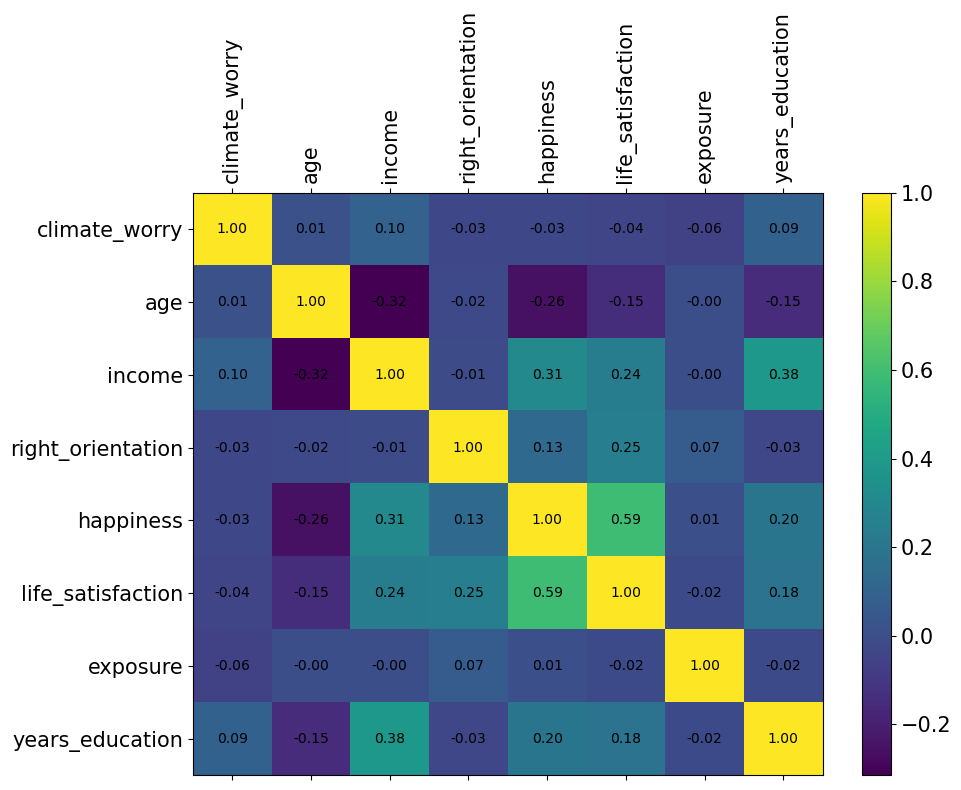

In [17]:
corr_df = df.iloc[:,[0,1,3,4,6,7,9,10]].corr()

corr_df.index = corr_df.columns

fig, ax = plt.subplots(figsize=(10, 8))

cax = ax.matshow(corr_df, aspect="auto")

fig.colorbar(cax)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))

ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticklabels(corr_df.columns)

for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        ax.text(
            j,
            i,
            f"{corr_df.iloc[i, j]:.2f}",
            va="center",
            ha="center"
        )

plt.rcParams.update({
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12
})
plt.tight_layout()
plt.show()

In [ ]:
hu_regions = {"HU": "Hungary","HU1": "Közép-Magyarország","HU11": "Budapest","HU110": "Budapest","HU12": "Pest",
    "HU120": "Pest","HU2": "Dunántúl","HU21": "Közép-Dunántúl","HU211": "Fejér","HU212": "Komárom-Esztergom",
    "HU213": "Veszprém","HU22": "Nyugat-Dunántúl","HU221": "Győr-Moson-Sopron","HU222": "Vas","HU223": "Zala",
    "HU23": "Dél-Dunántúl","HU231": "Baranya","HU232": "Somogy","HU233": "Tolna","HU3": "Alföld és Észak",
    "HU31": "Észak-Magyarország","HU311": "Borsod-Abaúj-Zemplén","HU312": "Heves","HU313": "Nógrád","HU32": "Észak-Alföld",
    "HU321": "Hajdú-Bihar","HU322": "Jász-Nagykun-Szolnok","HU323": "Szabolcs-Szatmár-Bereg","HU33": "Dél-Alföld",
    "HU331": "Bács-Kiskun","HU332": "Békés","HU333": "Csongrád","HUZ": "Extra-Regio NUTS 1","HUZZ": "Extra-Regio NUTS 2",
    "HUZZZ": "Extra-Regio NUTS 3","HU101": "Budapest","HU102": "Pest"}

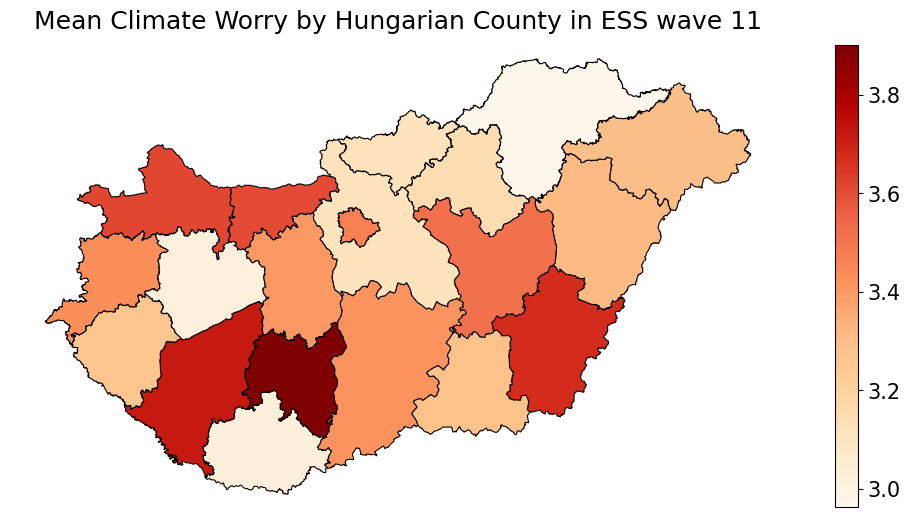

In [24]:
gdf = gpd.read_file("counties.geojson")

gdf["megye"] = (
    gdf["megye"]
    .str.strip()
    .str.lower()
)

df["region"] = (
    df["region"]
    .str.strip()
    .str.lower()
)

# aggregate county means
df_mean = (
    df[df["year"] == 3]
    .groupby("region", as_index=False)["climate_worry"]
    .mean()
)

# merge aggregated data
merged = gdf.merge(
    df_mean,
    left_on="megye",
    right_on="region",
    how="left"
)

# plot
fig, ax = plt.subplots(figsize=(10, 8))

merged.plot(
    column="climate_worry",
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={"shrink": 0.6},
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Mean Climate Worry by Hungarian County in ESS wave 11",
    fontsize=18
)

ax.axis("off")

plt.tight_layout()
plt.show()